# Generation of cavity detuning data through control-aware simulations

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import numpy as np
import control as ct
import pandas as pd

from scipy.linalg import block_diag
from matplotlib import pyplot as plt
from collections import namedtuple

import utils_data

### Analyzing machine-measured detuning data

In [2]:
# --! read data from files --!

data_path = '../../data/delay/detuning_24-03-2025_15-54_2'
data_frame = pd.read_csv(data_path, skiprows=23, dtype=np.float32, sep='\t', decimal=',')
detuning_data = data_frame.to_numpy()

data_path = '../../data/delay/gun_data2_w_kick_fft.csv'
data_frame = pd.read_csv(data_path, dtype=np.float32, sep=' ')
fft_with_kick = data_frame.to_numpy()

data_path = '../../data/delay/gun_data2_wo_kick_fft.csv'
dataframe = pd.read_csv(data_path, dtype=np.float32, sep=' ')
fft_without_kick = dataframe.to_numpy()

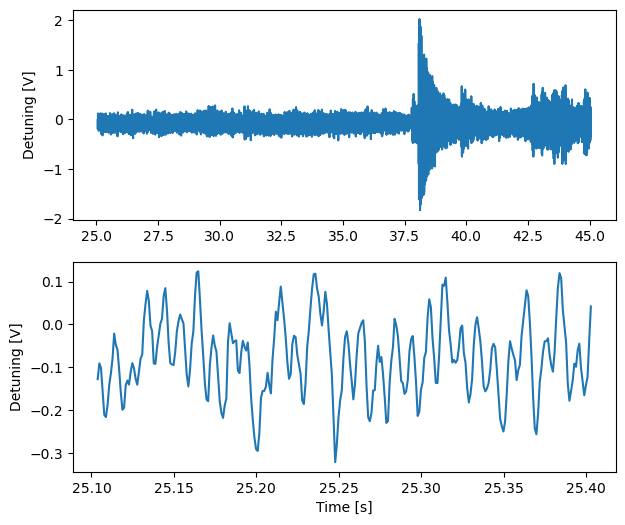

In [3]:
# --! display detuning data in time domain --!

plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.plot(detuning_data[:, 0], detuning_data[:, 1])
plt.ylabel('Detuning [V]')

plt.subplot(2,1,2)
plt.plot(detuning_data[50:350, 0], detuning_data[50:350, 1])
plt.ylabel('Detuning [V]')
plt.xlabel('Time [s]')

plt.show()

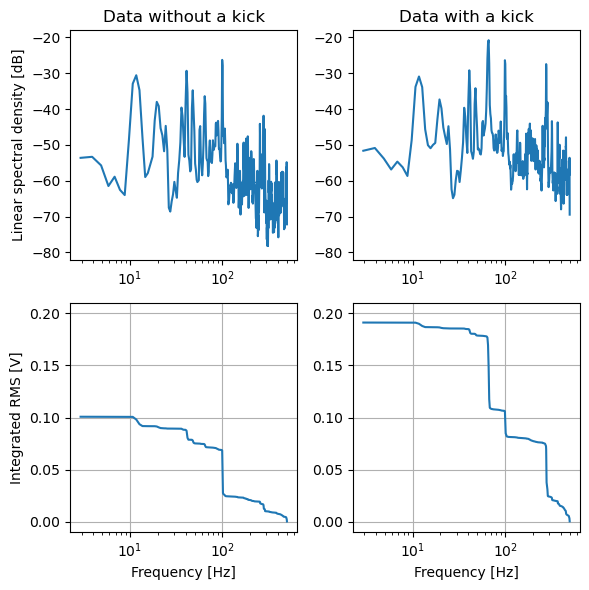

In [4]:
# --! display detuning data in frequency domain --!

plt.figure(figsize=(6, 6))

plt.subplot(2,2,1)
plt.title('Data without a kick')
plt.semilogx(fft_without_kick[:, 0], fft_without_kick[:, 1])
plt.ylim((-82,-18))
plt.ylabel('Linear spectral density [dB]')
plt.subplot(2,2,2)
plt.title('Data with a kick')
plt.semilogx(fft_with_kick[:, 0], fft_with_kick[:, 1])
plt.ylim((-82,-18))

plt.subplot(2,2,3)
plt.semilogx(fft_without_kick[:, 0], fft_without_kick[:, 2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Integrated RMS [V]')
plt.ylim((-0.01, 0.21))
plt.grid()
plt.subplot(2,2,4)
plt.semilogx(fft_with_kick[:, 0], fft_with_kick[:, 2])
plt.xlabel('Frequency [Hz]')
plt.ylim((-0.01, 0.21))
plt.grid()

plt.tight_layout()
plt.show()

### Implementing cavity equations for detuning simulation

In [5]:
# --! control options --!

lqr_q1, lqr_q2 = 1., 0.1
lqr_r = 1.0
est_q = 0.1
est_r = 1.0

In [6]:
# --! define helping routines for simulations --!

def make_rf_a(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [-hbw,     0.],
        [ 0.,    -hbw],
    ])

def make_rf_b(f, q):
    w     = 2 * np.pi * f
    hbw   = w/2/q  # < half-bandwidth of an rf cavity in rad/s

    return np.array([
        [hbw,    0.],
        [0.,    hbw],
    ])

def make_mm_a(f, q):
    """Constructs the matrix A of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [ 0,             1  ],
        [-np.square(w), -w/q],
    ])

def make_mm_b(f, k):
    """Constructs the matrix B of a single mechanical mode (mm)."""
    w = 2 * np.pi * f
    return np.array([
        [0               ],
        [k * np.square(w)],
    ])

def make_pzt(bw):
    tau = 1 / (2 * np.pi * bw)
    a = np.array([[-1 / tau]])
    b = np.array([[1 / tau]])
    c = np.array([[1]])
    d = np.array([[0]])

    return ct.ss(a, b, c, d)

def make_mm_system(f=np.array([100.]), q=np.array([1000.]), k=np.array([1.]), dt=0.):
    a = block_diag(*[make_mm_a(f, q) for f, q in zip(f, q)])
    b = np.concatenate([make_mm_b(f, k) for f, k in zip(f, k)], axis=0)
    c = np.tile(np.array([[1, 0]]), len(f))
    d = np.array(([[0]]))

    return ct.ss(a, b, c, d, dt, name='mm_plant')

def make_lqr(f, q, k, action_cost=1., dt=0.):

    lqr_plant = make_mm_system(f=f, q=q, k=k, dt=dt)

    # --! define maximum expected signal values
    det_max = 1.0      # detuning max [rad/s]
    vel_max = 200.0    # velocity max [rad/s^2]
    lqr_max = 10.0     # control max [V]
    x_norm = np.diag(np.tile([det_max, vel_max], len(f)))
    u_norm = lqr_max

    # --! normalize plant matrices
    a_norm = np.linalg.inv(x_norm) @ lqr_plant.A @ x_norm
    b_norm = np.linalg.inv(x_norm) @ lqr_plant.B * u_norm

    q_norm = np.diag(np.tile([lqr_q1, lqr_q2], len(f)))
    r_norm = np.diag([action_cost])

    k_norm, _, _ = ct.lqr(a_norm, b_norm, q_norm, r_norm)

    return lqr_plant, k_norm @ np.linalg.inv(x_norm)

def make_est(lqr_plant, q=0.1, r=0.1):

    init_uncertainty = np.eye(lqr_plant.nstates) * 0.1
    return ct.create_estimator_iosystem(lqr_plant, q, r, P0=init_uncertainty, name='estimator', inputs=['u[0]', 'u[1]'])

def cavity_update(t, x, u, param):

    # --! get parameters
    rf_f = param.get('rf_f')
    rf_q = param.get('rf_q')
    rf_v = param.get('rf_v')
    rf_len = param.get('rf_len')
    mm_control_used = param.get('mm_control_used')
    mm_f = param.get('mm_f')
    mm_q = param.get('mm_q')
    nmm = len(mm_f)
    mm_k = param.get('mm_k')
    mm_t = param.get('mm_t')

    # --! extract current state of a cavity field: real and imaginary components
    rf_x = np.array(x[:2]).reshape((-1, 1))

    # --! extract current states of all mechanical modes: displacements and velocities
    mm_x = np.array(x[2:]).reshape((-1, 1))

    # --! assemble input to cavity field: real and imaginary parts of a generator voltage
    rf_u = np.array([
        [rf_v[0]],
        [rf_v[1]]
    ])

    # --! compute input to mechanical mode: accelerating field gradient squared
    #
    # --! field gradient has units MV/m, but since we simulate only one cell,
    # --! and the length of one cell is passed as a parameter,
    # --! we need to adjust the total gradient
    rf_grad = np.sqrt(np.square(rf_x[0]) + np.square(rf_x[1]))
    rf_grad = rf_grad * rf_len
    rf_grad = np.square(rf_grad)

    # --! create rf matrices A and B
    rf_a = make_rf_a(rf_f, rf_q)
    rf_b = make_rf_b(rf_f, rf_q)

    # --! update detuning in rf matrix A
    mm_disp = np.sum([mm_x[2*j] for j in range(nmm)])
    rf_a[0, 1] = -mm_disp
    rf_a[1, 0] =  mm_disp

    # --! assemble mechanical mode matrices: A and B
    mm_a = block_diag(*[make_mm_a(f, q) for f, q in zip(mm_f, mm_q)])
    mm_b_field = np.concatenate([make_mm_b(f, k) for f, k in zip(mm_f, mm_k)], axis=0)
    mm_b_control = np.concatenate([make_mm_b(f, k) for f, k in zip(mm_f, mm_k)], axis=0)

    # --! split matrix B of mechanical modes into per-mode B matrices
    mm_b_mode = np.split(mm_b_field, mm_b_field.shape[0] // 2, axis=0)

    # --! split mechanical time boundary array into per-mode parts
    mm_t_mode = np.split(mm_t, mm_t.shape[0], axis=0) # split into rows

    for mat, timespan in zip(mm_b_mode, mm_t_mode):
        if not (timespan[0, 0] <= t and t < timespan[0, 1]):
            mat[:] = 0.

    # --! mechanical modes are excited by field gradient ...
    mm_u_field = rf_grad

    mm_u_control = 0.
    if mm_control_used:
        # --! ... and compensated by control (if used)
        mm_u_control = u

    # --! calculate derivatives
    rf_dx = rf_a @ rf_x + rf_b @ rf_u
    mm_dx = mm_a @ mm_x + mm_b_field * mm_u_field + mm_b_control * mm_u_control

    return np.array([
        *rf_dx.flatten(),
        *mm_dx.flatten(),
    ])

def cavity_output(t, x, u, param):
    """ Outputs summed positions of all mechanical modes. """
    mm_x = x[2:]
    nmm  = len(mm_x) // 2
    mm_d = np.sum([mm_x[2*j] for j in range(nmm)])
    #mm_v = np.sum([mm_x[2*j + 1] for j in range(nmm)])
    return np.array([mm_d])

def control_output(t, x, u, param):

    # --! get parameters
    lqr_k = param.get('lqr_k')

    est_x = np.array(u).reshape((-1, 1))
    return -(lqr_k @ est_x)

def sim_cavity_control(t,
                       skip_nsample=50,
                       lqr_used=True, lqr_r=1.0,
                       mm_f=np.array([40.]), mm_q=np.array([400.]), mm_k=np.array([1.]), mm_t=np.array([[-1., -1.]]),
                       plotted=False,
                       solve_method='RK45'):
    """ Simulates cavity equations under control. """

    # --! actualize time boundaries
    for timespan in np.split(mm_t, mm_t.shape[0], axis=0): # split into rows
            if timespan[0, 0]==-1.:
                timespan[0, 0] = t[0]
            if timespan[0, 1]==-1.:
                timespan[0, 1] = t[-1]

    # --! prepare parameters for cavity plant simulation
    cavity_param = {
        'rf_f' : 1.3e9,
        'rf_q' : 4e6,
        'rf_v' : [9.5, 0.],
        'rf_len' : 0.1615,
        'mm_control_used' : lqr_used,
        'mm_f' : mm_f,
        'mm_q' : mm_q,
        'mm_k' : mm_k,
        'mm_t' : mm_t,
    }

    # --! number of cavity states includes two rf states and the number of mechaical modes times two
    nstate = 2 + 2 * len(cavity_param.get('mm_f'))

    # --! wrap a cavity plant in a nonlinear input/output system
    cavity = ct.nlsys(
        cavity_update, cavity_output,
        states=nstate,
        name='cavity',
        inputs=1, outputs=1,
        params=cavity_param)

    # --! create cavity control
    control_f = np.array([100., 40., 10.])
    control_q = np.array([1000., 400., 100.])
    control_k = np.array([1., 1., 1.])
    lqr_plant, lqr_k = make_lqr(f=control_f, q=control_q, k=control_k, action_cost=lqr_r)
    estimator = make_est(lqr_plant, q=est_q, r=est_r)

    control_param = {
        'lqr_k' : lqr_k,
    }

    # --! LQR is a full-state feedback, so the number of inputs is the number of controlled mechanical states
    control_ninput = lqr_plant.nstates

    # --! wrap cavity control in a nonlinear input/output system
    control = ct.nlsys(
        None, control_output,
        name='control',
        inputs=control_ninput, outputs=1,
        params=control_param)

    # --! build a closed loop system
    cavity_closed = ct.interconnect(
        [control, estimator, cavity],
        connections=[
            ['cavity.u', 'control.y'],
            ['estimator.u[0]', 'cavity.y'],
            ['estimator.u[1]', 'control.y'],
            ['control.u', 'estimator.xhat'],
        ],
        outlist=['cavity.y', 'control.y'],
        outputs=['dw', 'pzt'],
    )

    # --! display input-output response
    resp = ct.input_output_response(cavity_closed, t, solve_ivp_method=solve_method)
    if plotted:
        resp.plot(plot_inputs=False)

    timeseries_nsample = resp.outputs[0].shape[0] - skip_nsample

    return np.concatenate(
        [
            resp.outputs[0][skip_nsample:].reshape(-1, 1),
            resp.outputs[1][skip_nsample:].reshape(-1, 1),
        ], axis=1).reshape(-1, timeseries_nsample, 2)


# --! time definitions for simulations
timeseries_nsample = 300
skip_nsample = 50
timestep = 0.001
t = np.arange(0., timeseries_nsample*timestep, timestep)

# --! mechanical mode properties
mechanical_mode = namedtuple('mechanical_mode', 'f q k t')

### Running cavity simulations to obtain detuning data

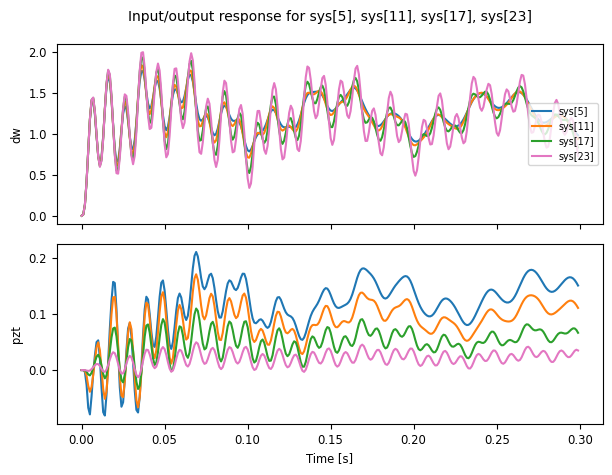

In [7]:
# --! obtain stationary detuning data --!

stat_data = []

# --! define stationary mechanical modes that perturb our cavity
mm100 = mechanical_mode(100., 1000., 0.3, [-1., -1.])
mm40 = mechanical_mode(40., 400., 0.1, [-1., -1.])
mm10 = mechanical_mode(10., 100., 0.1, [-1., -1.])

# --! set flags and parameters for simulation
sim_skipped = [False, False, False, False]
lqr_r = [1., 10., 100., 1000.]
lqr_used = [True, True, True, True]

for skipped, r, used in zip(sim_skipped, lqr_r, lqr_used):

    if not skipped:
        stat_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm100.f]),
                mm_q=np.array([mm100.q]),
                mm_k=np.array([mm100.k]),
                mm_t=np.array([mm100.t]),
                plotted=False))

    stat_data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm40.f]),
            mm_q=np.array([mm40.q]),
            mm_k=np.array([mm40.k]),
            mm_t=np.array([mm40.t]),
            plotted=False))

    stat_data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm10.f]),
            mm_q=np.array([mm10.q]),
            mm_k=np.array([mm10.k]),
            mm_t=np.array([mm10.t]),
            plotted=False))

    stat_data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm10.f]),
            mm_q=np.array([mm100.q, mm10.q]),
            mm_k=np.array([mm100.k, mm10.k]),
            mm_t=np.array([mm100.t, mm10.t]),
            plotted=False))

    stat_data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f]),
            mm_q=np.array([mm100.q, mm40.q]),
            mm_k=np.array([mm100.k, mm40.k]),
            mm_t=np.array([mm100.t, mm40.t]),
            plotted=False))

    stat_data.append(
        sim_cavity_control(
            t, skip_nsample=skip_nsample,
            lqr_used=used, lqr_r=r,
            mm_f=np.array([mm100.f, mm40.f, mm10.f]),
            mm_q=np.array([mm100.q, mm40.q, mm10.q]),
            mm_k=np.array([mm100.k, mm40.k, mm10.k]),
            mm_t=np.array([mm100.t, mm40.t, mm10.t]),
            plotted=True))


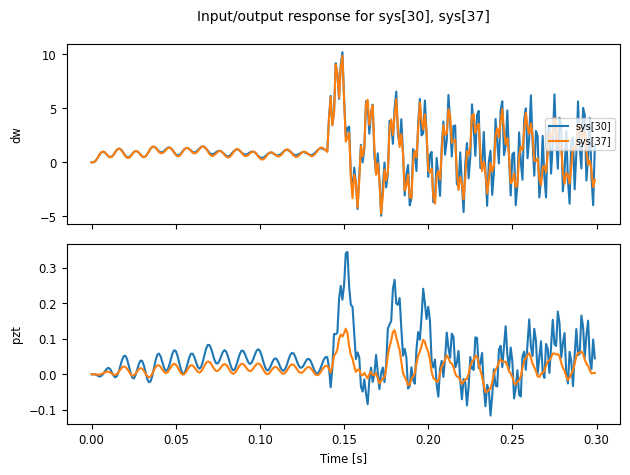

In [8]:
# --! obtain transient detuning data --!

trans_data = []

# --! define transient mechanical modes that perturb our cavity
mm64 = mechanical_mode(64., 50., 1., [0.1, 0.11])
mm285 = mechanical_mode(285., 100., 1., [0.1, 0.11])
mm100 = mechanical_mode(100., 1000., 0.2, [-1., -1.])
mm40 = mechanical_mode(40., 140., 0.08, [-1., -1.])
mm10 = mechanical_mode(10., 80., 0.08, [-1., -1.])

# --! set flags and parameters for simulation
sim_skipped = [True, True, False, False]
lqr_r = [1.0, 10.0, 100.0, 1000.0]
lqr_used = [True, True, True, True]

solver_method = 'BDF'

for skipped, r, used in zip(sim_skipped, lqr_r, lqr_used):

    if not skipped:
        trans_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm64.f, mm285.f, mm100.f]),
                mm_q=np.array([mm64.q, mm285.q, mm100.q]),
                mm_k=np.array([mm64.k, mm285.k, mm100.k]),
                mm_t=np.array([mm64.t, mm285.t, mm100.t]),
                plotted=False,
                solve_method=solver_method))

    if not skipped:
        trans_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm64.f, mm285.f, mm100.f]),
                mm_q=np.array([mm64.q, mm285.q, mm100.q]),
                mm_k=np.array([mm64.k, mm285.k, mm100.k]),
                mm_t=np.array([[0.13, 0.14], [0.13, 0.14], mm100.t]),
                plotted=False,
                solve_method=solver_method))

    if not skipped:
        trans_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm64.f, mm285.f, mm100.f, mm40.f]),
                mm_q=np.array([mm64.q, mm285.q, mm100.q, mm40.q]),
                mm_k=np.array([mm64.k, mm285.k, mm100.k, mm40.k]),
                mm_t=np.array([mm64.t, mm285.t, mm100.t, mm40.t]),
                plotted=False,
                solve_method=solver_method))

    if not skipped:
        trans_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm64.f, mm285.f, mm100.f, mm40.f]),
                mm_q=np.array([mm64.q, mm285.q, mm100.q, mm40.q]),
                mm_k=np.array([mm64.k, mm285.k, mm100.k, mm40.k]),
                mm_t=np.array([[0.15, 0.16], [0.15, 0.16], mm100.t, mm40.t]),
                plotted=False,
                solve_method=solver_method))

    if not skipped:
        trans_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm64.f, mm285.f, mm100.f, mm10.f]),
                mm_q=np.array([mm64.q, mm285.q, mm100.q, mm10.q]),
                mm_k=np.array([mm64.k, mm285.k, mm100.k, mm10.k]),
                mm_t=np.array([mm64.t, mm285.t, mm100.t, mm10.t]),
                plotted=False,
                solve_method=solver_method))

    if not skipped:
        trans_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm64.f, mm285.f, mm100.f, mm10.f]),
                mm_q=np.array([mm64.q, mm285.q, mm100.q, mm10.q]),
                mm_k=np.array([mm64.k, mm285.k, mm100.k, mm10.k]),
                mm_t=np.array([[0.15, 0.16], [0.15, 0.16], mm100.t, mm10.t]),
                plotted=False,
                solve_method=solver_method))

    if not skipped:
        trans_data.append(
            sim_cavity_control(
                t, skip_nsample=skip_nsample,
                lqr_used=used, lqr_r=r,
                mm_f=np.array([mm64.f, mm285.f, mm100.f, mm40.f, mm10.f]),
                mm_q=np.array([mm64.q, mm285.q, mm100.q, mm40.q, mm10.q]),
                mm_k=np.array([mm64.k, mm285.k, mm100.k, mm40.k, mm10.k]),
                mm_t=np.array([[0.14, 0.15], [0.14, 0.15], mm100.t, mm40.t, mm10.t]),
                plotted=True,
                solve_method=solver_method))


In [9]:
# --! save simulated data --!

datasaved = False

if datasaved:
    savedata = np.concatenate(stat_data, axis=0)
    print(f'stationary data saved with a shape {savedata.shape}')
    savedir = '../../data/delay'
    utils_data.write_datafile(f'{savedir}/gun_sim_stat', savedata)

    savedata = np.concatenate(trans_data, axis=0)
    print(f'transient data saved with a shape {savedata.shape}')
    savedir = '../../data/delay'
    utils_data.write_datafile(f'{savedir}/gun_sim_trans', savedata)